In [ ]:

import sys, os
sys.path.append(os.pardir)
import numpy as np
from typing import Dict, List
import matplotlib.pyplot as plt

from libs.network import NeuralNet
from libs.trainer import Trainer
from libs.util import smooth_curve

# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [10]:
# 加载数据集
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)

print(f"x_train: {x_train.shape}")
print(f"t_train: {t_train.shape}")
print(f"x_test: {x_test.shape}")
print(f"t_test: {t_test.shape}")

save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
x_train: (60000, 784)
t_train: (60000, 10)
x_test: (10000, 784)
t_test: (10000, 10)


In [11]:
def start_train(optimizer: str='sgd', optimizer_param: Dict={'lr': 0.01}, hidden_size_list: List[int]=[100, 100, 100, 100, 100, 100], 
                epochs: int=50, mini_batch_size: int=100, activation: str="relu", weight_scale: str|float="he", 
                weight_decay_lambda: float=0.0, use_dropout: bool=False, dropout_ration: float=0.5, use_batchnorm=False,
                verbose=False
    ) -> List[float]:
    trainer = Trainer(
        network=NeuralNet(input_size=x_train.shape[1], hidden_size_list=hidden_size_list, 
                              output_size=t_train.shape[1], activation=activation, weight_scale=weight_scale, 
                              weight_decay_lambda=weight_decay_lambda, 
                              use_dropout=use_dropout, dropout_ration=dropout_ration, use_batchnorm=use_batchnorm, verbose=verbose),
        x_train=x_train,
        t_train=t_train,
        x_test=x_test,
        t_test=t_test,
        optimizer=optimizer,
        optimizer_param=optimizer_param,
        epochs=epochs,
        mini_batch_size=mini_batch_size,
        verbose=verbose
    )
    trainer.train()
    return trainer.train_loss_list, trainer.train_acc_list, trainer.test_acc_list

def show_train_acc_and_test_acc(result_list: List[Dict]) -> None:
    """
    显示多个实验结果的训练和测试准确率对比图
    
    Args:
        result_list: 包含实验结果的列表，每个元素包含 title, train_acc_list, test_acc_list
    """
    if not result_list:
        print("没有可显示的结果")
        return
    
    # 创建子图：左侧显示训练准确率，右侧显示测试准确率
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 定义颜色列表
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
    
    # 绘制训练准确率
    for i, result in enumerate(result_list):
        color = colors[i % len(colors)]
        train_acc_smooth = smooth_curve(result['train_acc_list'])
        ax1.plot(train_acc_smooth, label=result['title'], color=color, linewidth=2)
    
    ax1.set_title('训练准确率对比', fontsize=14, fontweight='bold')
    ax1.set_xlabel('训练轮次')
    ax1.set_ylabel('准确率')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 绘制测试准确率
    for i, result in enumerate(result_list):
        color = colors[i % len(colors)]
        test_acc_smooth = smooth_curve(result['test_acc_list'])
        ax2.plot(test_acc_smooth, label=result['title'], color=color, linewidth=2)
    
    ax2.set_title('测试准确率对比', fontsize=14, fontweight='bold')
    ax2.set_xlabel('训练轮次')
    ax2.set_ylabel('准确率')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印最终准确率统计
    print("\n=== 实验结果汇总 ===")
    print(f"{'实验名称':<25} {'最终训练准确率':<15} {'最终测试准确率':<15} {'过拟合程度':<10}")
    print("-" * 70)
    
    for result in result_list:
        final_train_acc = result['train_acc_list'][-1]
        final_test_acc = result['test_acc_list'][-1]
        overfit_degree = final_train_acc - final_test_acc
        
        print(f"{result['title']:<25} {final_train_acc:<15.4f} {final_test_acc:<15.4f} {overfit_degree:<10.4f}")

# 为了向后兼容，保留原函数的简化版本
def show_single_experiment(title: str, train_acc_list: List[float], test_acc_list: List[float]) -> None:
    """显示单个实验的结果"""
    plt.figure(figsize=(10, 6))
    plt.plot(smooth_curve(train_acc_list), label='Train Accuracy', color='blue')
    plt.plot(smooth_curve(test_acc_list), label='Test Accuracy', color='orange')
    plt.title(title)
    plt.xlabel('训练轮次')
    plt.ylabel('正确率')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

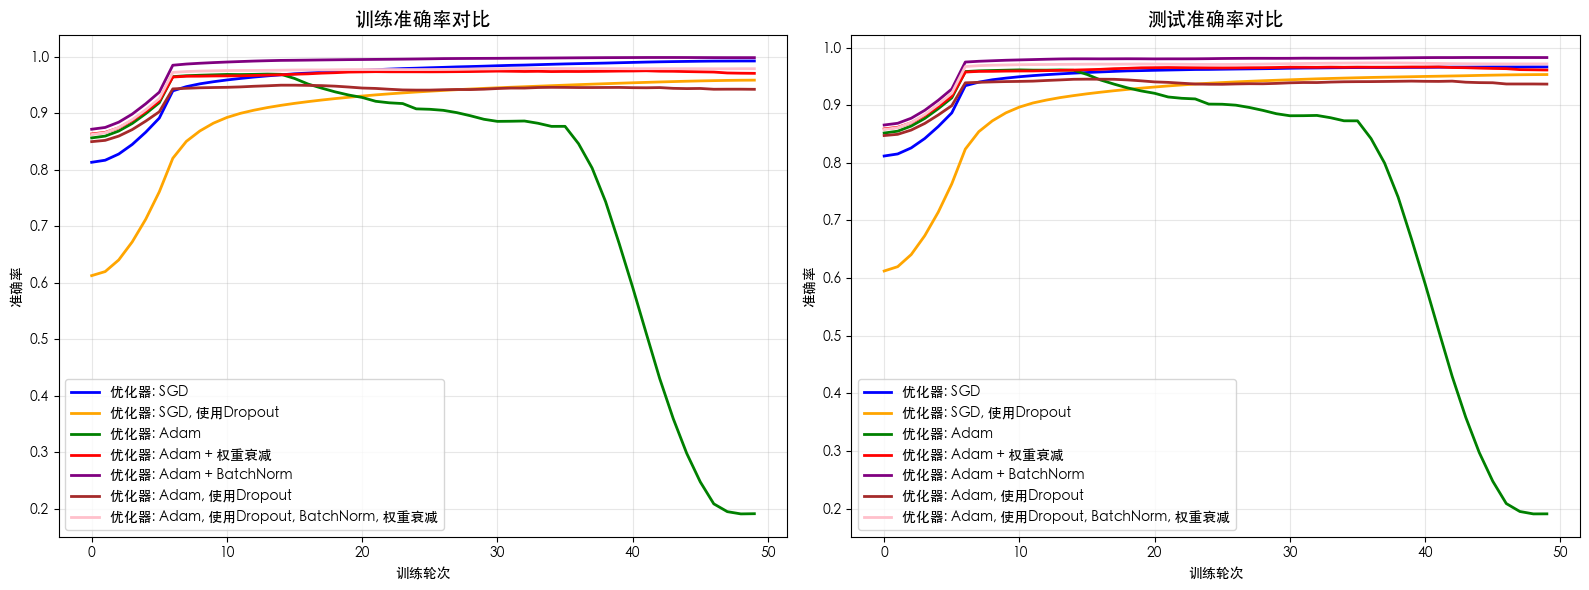


=== 实验结果汇总 ===
实验名称                      最终训练准确率         最终测试准确率         过拟合程度     
----------------------------------------------------------------------
优化器: SGD                  0.9934          0.9675          0.0259    
优化器: SGD, 使用Dropout       0.9599          0.9536          0.0063    
优化器: Adam                 0.1923          0.1968          -0.0045   
优化器: Adam + 权重衰减          0.9769          0.9661          0.0108    
优化器: Adam + BatchNorm     0.9980          0.9816          0.0164    
优化器: Adam, 使用Dropout      0.9489          0.9435          0.0054    
优化器: Adam, 使用Dropout, BatchNorm, 权重衰减 0.9798          0.9731          0.0067    


In [15]:

# 使用SGD优化器的训练集和测试集准确率
result = []
_, train_acc_list, test_acc_list = start_train(
    optimizer='sgd', 
    optimizer_param={'lr': 0.01}, 
    weight_decay_lambda=2.68e-05 # 权重衰减系数
)
result.append({
    'title': '优化器: SGD', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})
_, train_acc_list, test_acc_list = start_train(
    optimizer='sgd', 
    optimizer_param={'lr': 0.01}, 
    use_dropout=True,
    dropout_ration=0.2
)
result.append({
    'title': '优化器: SGD, 使用Dropout', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})


# 注意: adam 如何不进行正则化处理, 会出现优化器在训练早期表现出色，能够快速将准确率提升到较高水平（如 90%），但随后准确率可能出现持续下滑
# 需要进行正则化处理, 比如使用权重衰减或 Dropout 或 BatchNorm 
_, train_acc_list, test_acc_list = start_train(
    optimizer='adam', 
    optimizer_param={'lr': 0.01, 'beta1': 0.9, 'beta2': 0.999}, 
)
result.append({
    'title': '优化器: Adam', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})

_, train_acc_list, test_acc_list = start_train(
    optimizer='adam', 
    optimizer_param={'lr': 0.01, 'beta1': 0.9, 'beta2': 0.999}, 
    weight_decay_lambda=2.68e-05,  # 权重衰减系数
)
result.append({
    'title': '优化器: Adam + 权重衰减', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})

_, train_acc_list, test_acc_list = start_train(
    optimizer='adam', 
    optimizer_param={'lr': 0.01, 'beta1': 0.9, 'beta2': 0.999}, 
    use_batchnorm=True,
)
result.append({
    'title': '优化器: Adam + BatchNorm', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})

_, train_acc_list, test_acc_list = start_train(
    optimizer='adam', 
    optimizer_param={'lr': 0.01, 'beta1': 0.9, 'beta2': 0.999}, 
    use_dropout=True,
    dropout_ration=0.2
)
result.append({
    'title': '优化器: Adam, 使用Dropout', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})

_, train_acc_list, test_acc_list = start_train(
    optimizer='adam', 
    optimizer_param={'lr': 0.01, 'beta1': 0.9, 'beta2': 0.999}, 
    use_dropout=True,
    dropout_ration=0.2,
    use_batchnorm=True,
    weight_decay_lambda=2.68e-05  # 权重衰减系数
)
result.append({
    'title': '优化器: Adam, 使用Dropout, BatchNorm, 权重衰减', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})


show_train_acc_and_test_acc(result)

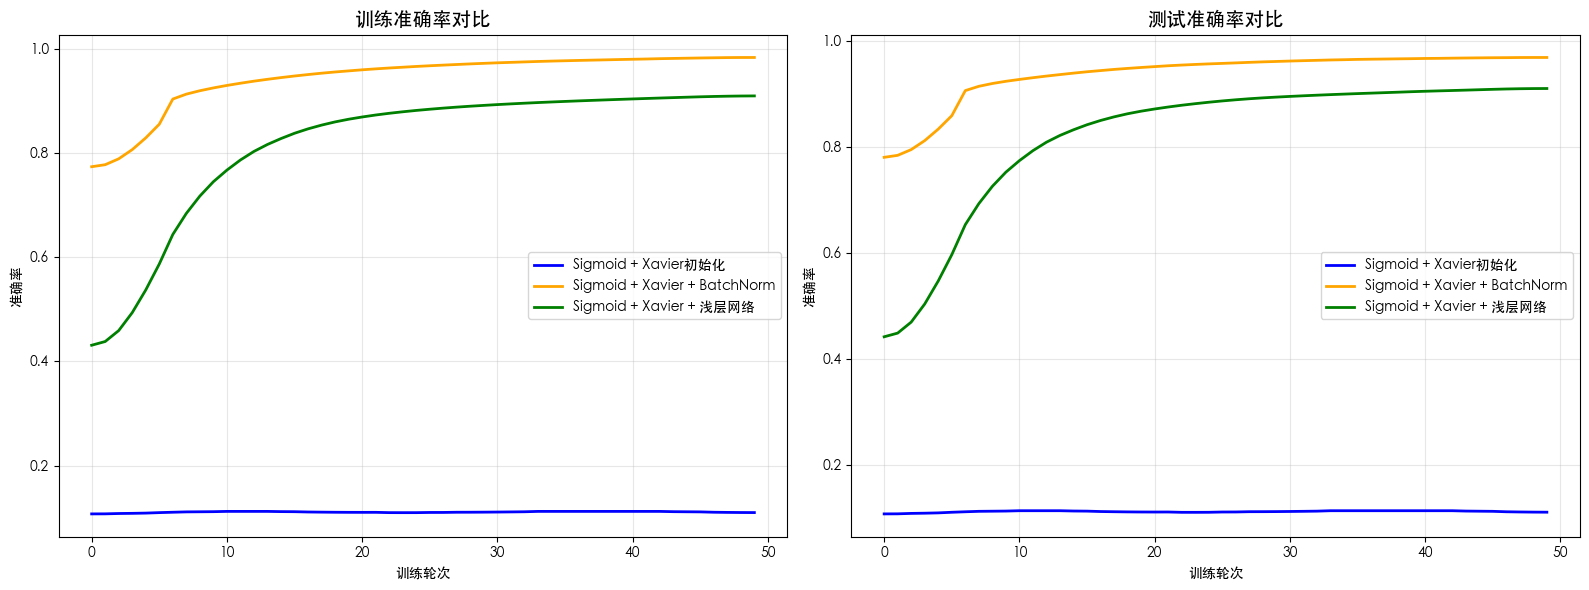


=== 实验结果汇总 ===
实验名称                      最终训练准确率         最终测试准确率         过拟合程度     
----------------------------------------------------------------------
Sigmoid + Xavier初始化       0.1124          0.1135          -0.0011   
Sigmoid + Xavier + BatchNorm 0.9839          0.9690          0.0149    
Sigmoid + Xavier + 浅层网络   0.9111          0.9135          -0.0024   


In [5]:
# 注意: 
# Sigmoid 函数在输入值较大或较小时，梯度接近 0
#   - 当输入 ≥5 或 ≤-5 时，sigmoid 的梯度几乎为 0
#   - 这导致神经元在训练过程中"死亡"，无法更新权重
# 当层隐藏层数量较多时，Sigmoid 函数的梯度消失问题会更加严重
# 
# 解决方案:
# 1. 优先使用 ReLU 家族：ReLU、LeakyReLU、ELU 等
# 2. 如必须用 sigmoid：配合 Batch Normalization 使用
# 3. 控制网络深度：对于 sigmoid，建议不超过 2-3 层隐藏层
# 4. 使用残差连接：对于更深的网络，考虑 ResNet 架构

sigmoid_result = []

_, train_acc_list, test_acc_list = start_train(
    optimizer='sgd', 
    optimizer_param={'lr': 0.01}, 
    activation="sigmoid", # 使用Sigmoid激活函数
    weight_scale="xavier", # 使用Xavier初始化
)
sigmoid_result.append({
    'title': 'Sigmoid + Xavier初始化', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})

_, train_acc_list, test_acc_list = start_train(
    optimizer='sgd', 
    optimizer_param={'lr': 0.01}, 
    activation="sigmoid", # 使用Sigmoid激活函数
    weight_scale="xavier", # 使用Xavier初始化
    use_batchnorm=True, # 使用批归一化
)
sigmoid_result.append({
    'title': 'Sigmoid + Xavier + BatchNorm', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})

_, train_acc_list, test_acc_list = start_train(
    optimizer='sgd', 
    optimizer_param={'lr': 0.01}, 
    activation="sigmoid", # 使用Sigmoid激活函数
    weight_scale="xavier", # 使用Xavier初始化
    hidden_size_list=[100, 100], # 减少隐藏层数量
)
sigmoid_result.append({
    'title': 'Sigmoid + Xavier + 浅层网络', 
    'train_acc_list': train_acc_list, 
    'test_acc_list': test_acc_list
})

show_train_acc_and_test_acc(sigmoid_result)